In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
plt.rcParams["font.size"] = 12

Loading subfiles:  13%|█▎        | 25/192 [00:00<00:02, 72.30subfiles/s] 



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-07-09/nucleo__nu__2/algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)
shape: (1, 91)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─

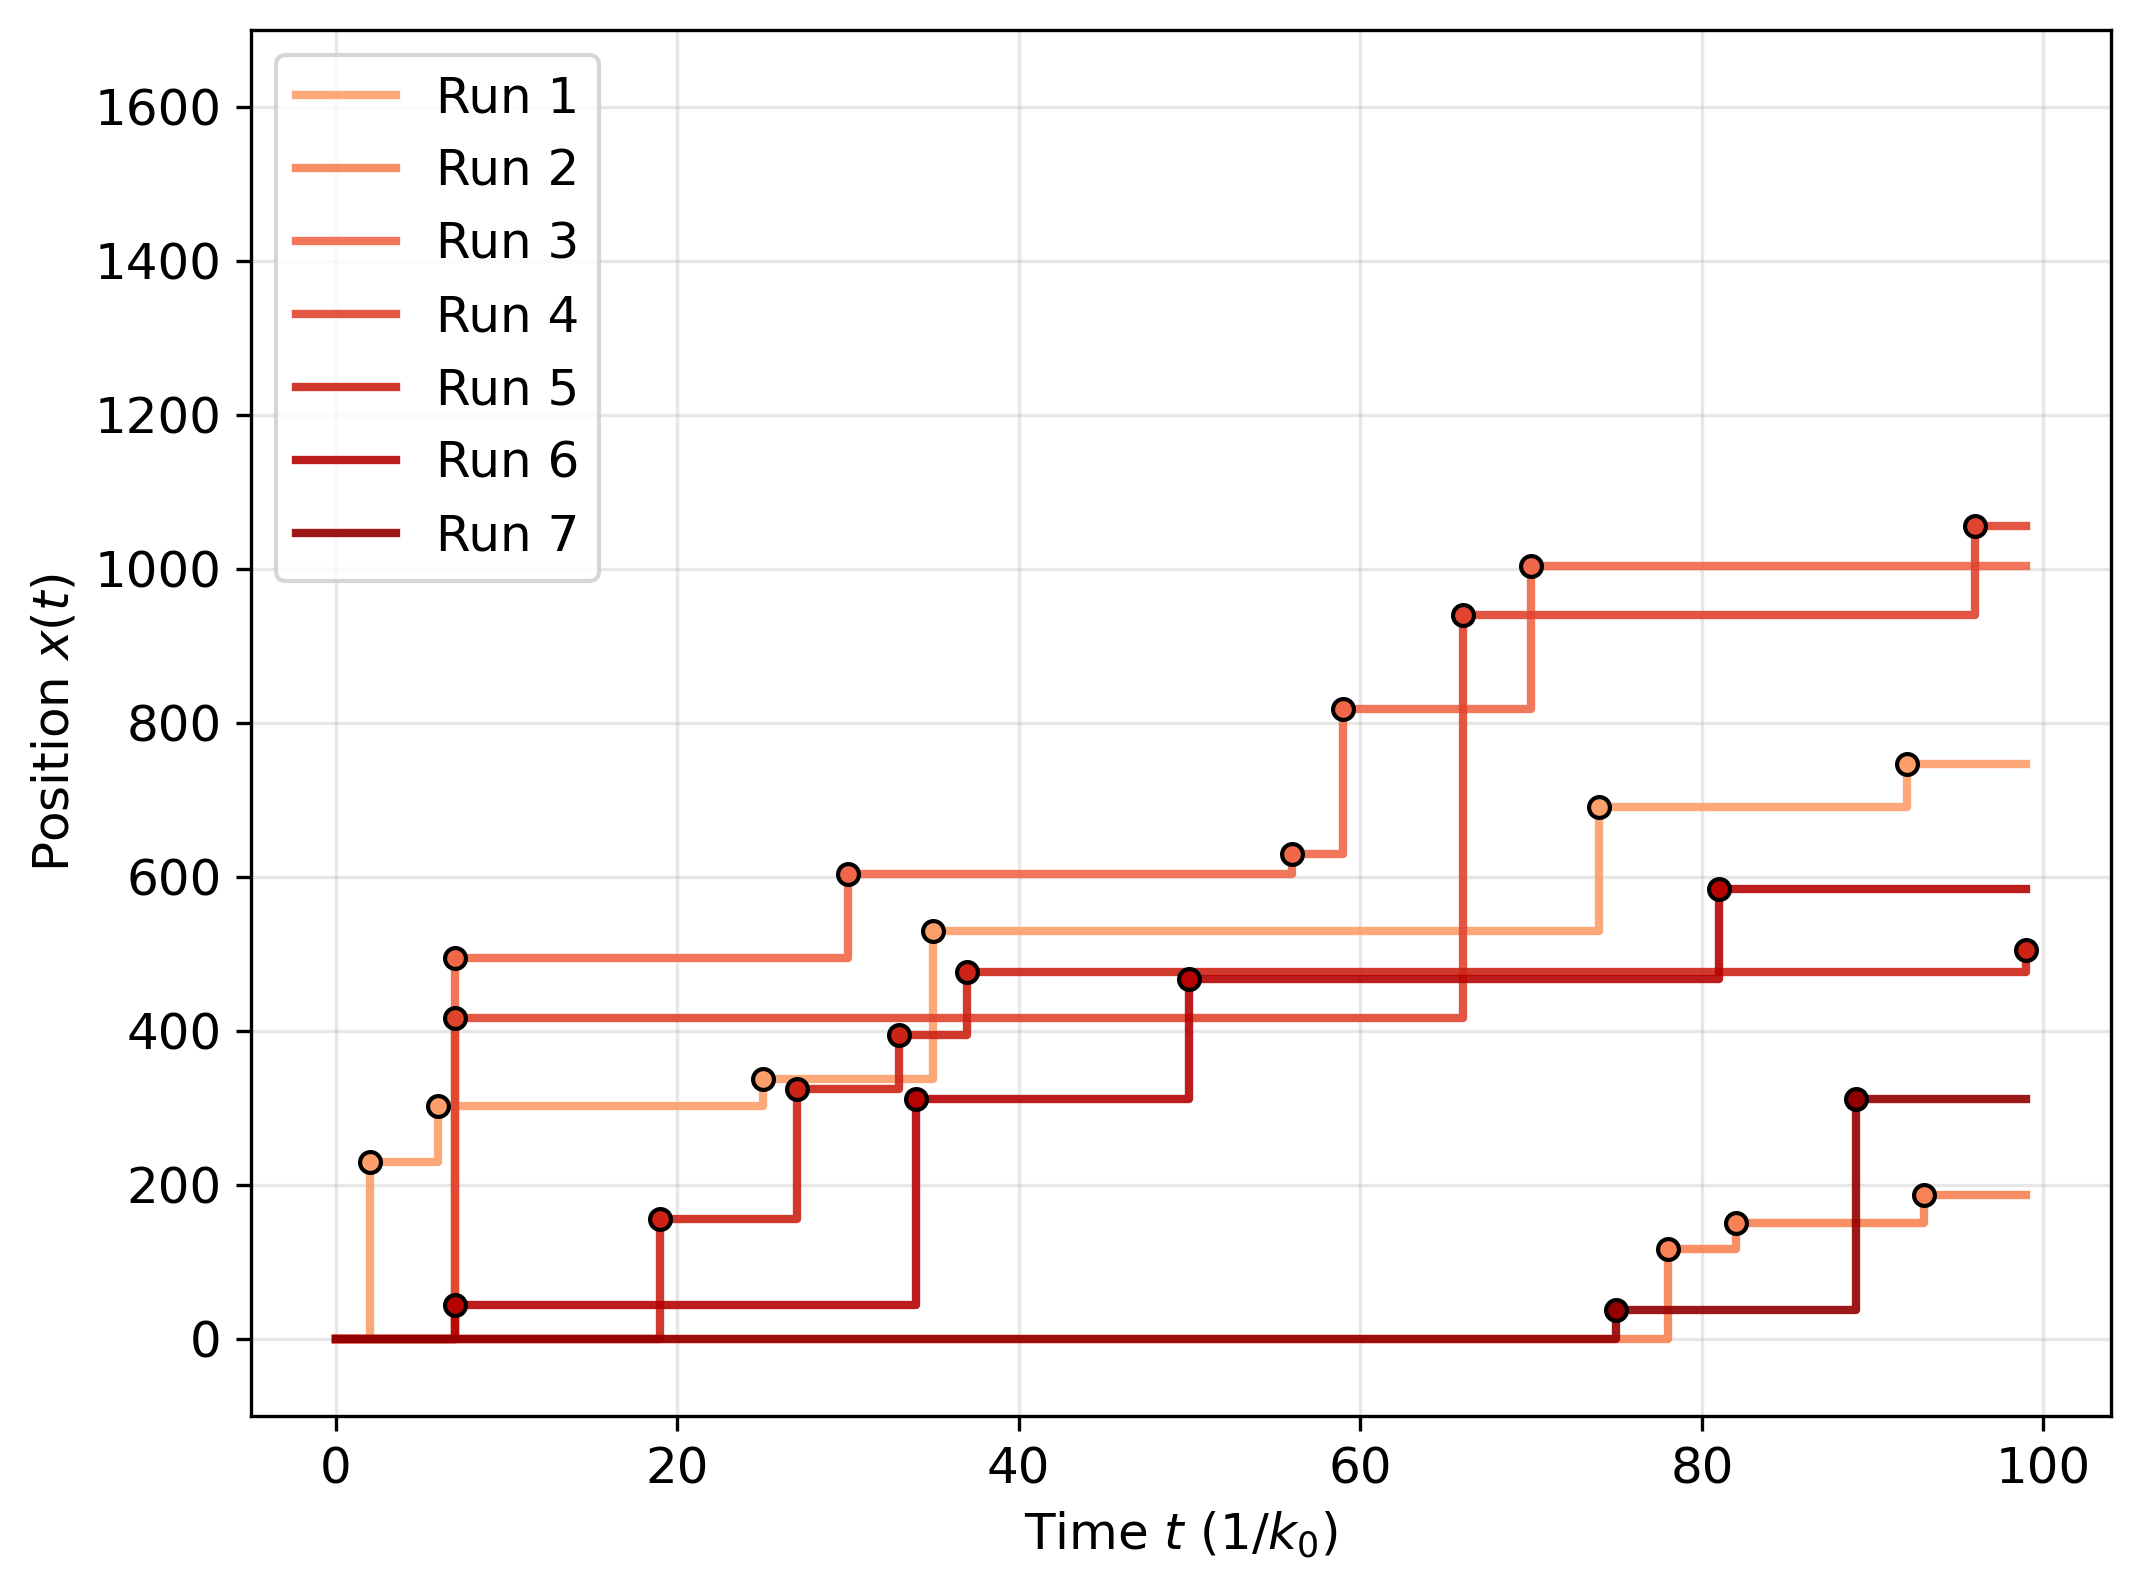

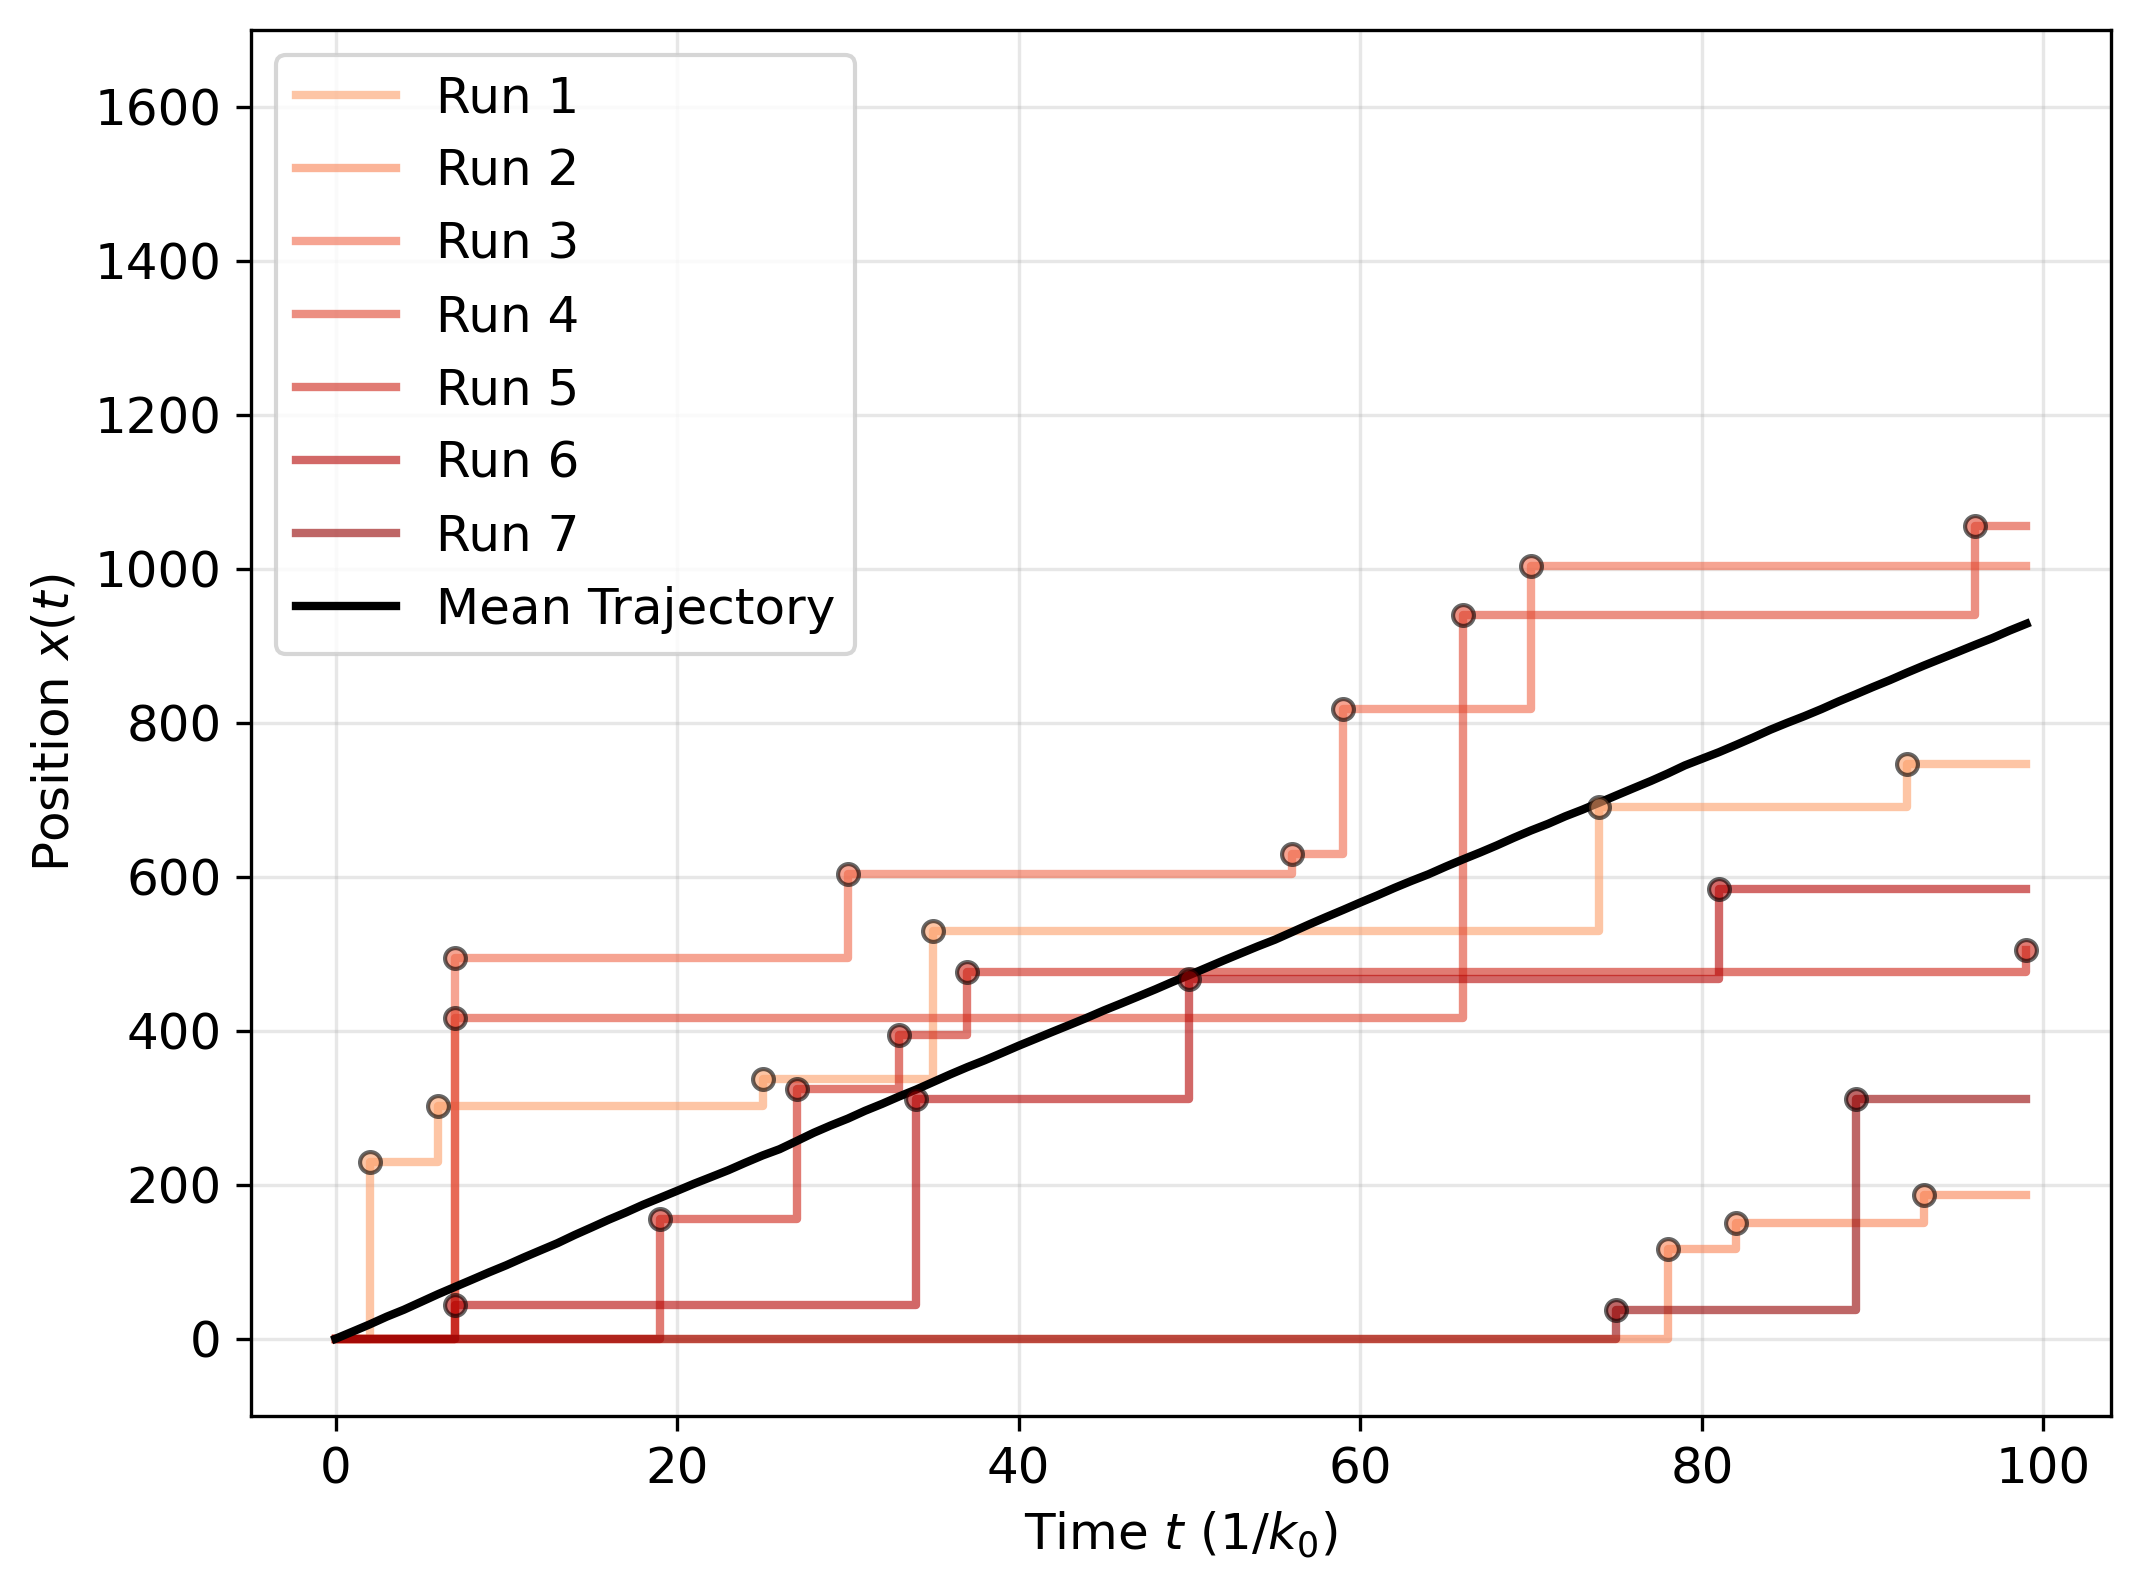

In [2]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",

    "land": "homogen",
    "s": 150,
    "l": 10,
    "bpmin": 0,

    "mu": 150,
    "theta": 100,

    "nt": 10_000,
}

df = find_parquet_and_load(**params)
print(df)


results = df["results"][0].to_numpy()
times = df["times"][0].to_numpy()
results_mean = df["results_mean"][0].to_numpy()

colors = plt.cm.OrRd(np.linspace(0.45, 0.95, 7))

plt.figure(figsize=(8, 6), dpi=300)

for i, color in enumerate(colors):

    trajectory = results[i]

    # Trajectoire en escalier
    plt.step(
        times,
        trajectory,
        where="post",
        color=color,
        alpha=0.9,
        linewidth=2,
        label=f"Run {i+1}"
    )

    # Détection des événements de saut
    jumps = np.where(np.diff(trajectory) != 0)[0] + 1

    plt.scatter(
        times[jumps],
        trajectory[jumps],
        color=color,
        edgecolor="black",
        s=25,
        zorder=3
    )

plt.xlabel(r"Time $t~(1/k_0)$")
plt.ylabel(r"Position $x(t)$")
plt.ylim(-100,1700)
plt.grid(True, alpha=0.30)
plt.legend()
plt.show()


plt.figure(figsize=(8, 6), dpi=300)

for i, color in enumerate(colors):

    trajectory = results[i]

    # Trajectoire en escalier
    plt.step(
        times,
        trajectory,
        where="post",
        color=color,
        alpha=0.6,
        linewidth=2,
        label=f"Run {i+1}"
    )

    # Détection des événements de saut
    jumps = np.where(np.diff(trajectory) != 0)[0] + 1

    plt.scatter(
        times[jumps],
        trajectory[jumps],
        color=color,
        edgecolor="black",
        s=25,
        zorder=3,
        alpha=0.6
    )

plt.plot(times, results_mean, color="black", linewidth=2, label="Mean Trajectory")
plt.xlabel(r"Time $t~(1/k_0)$")
plt.ylabel(r"Position $x(t)$")
plt.ylim(-100,1700)
plt.legend()
plt.grid(True, alpha=0.30)
plt.show()

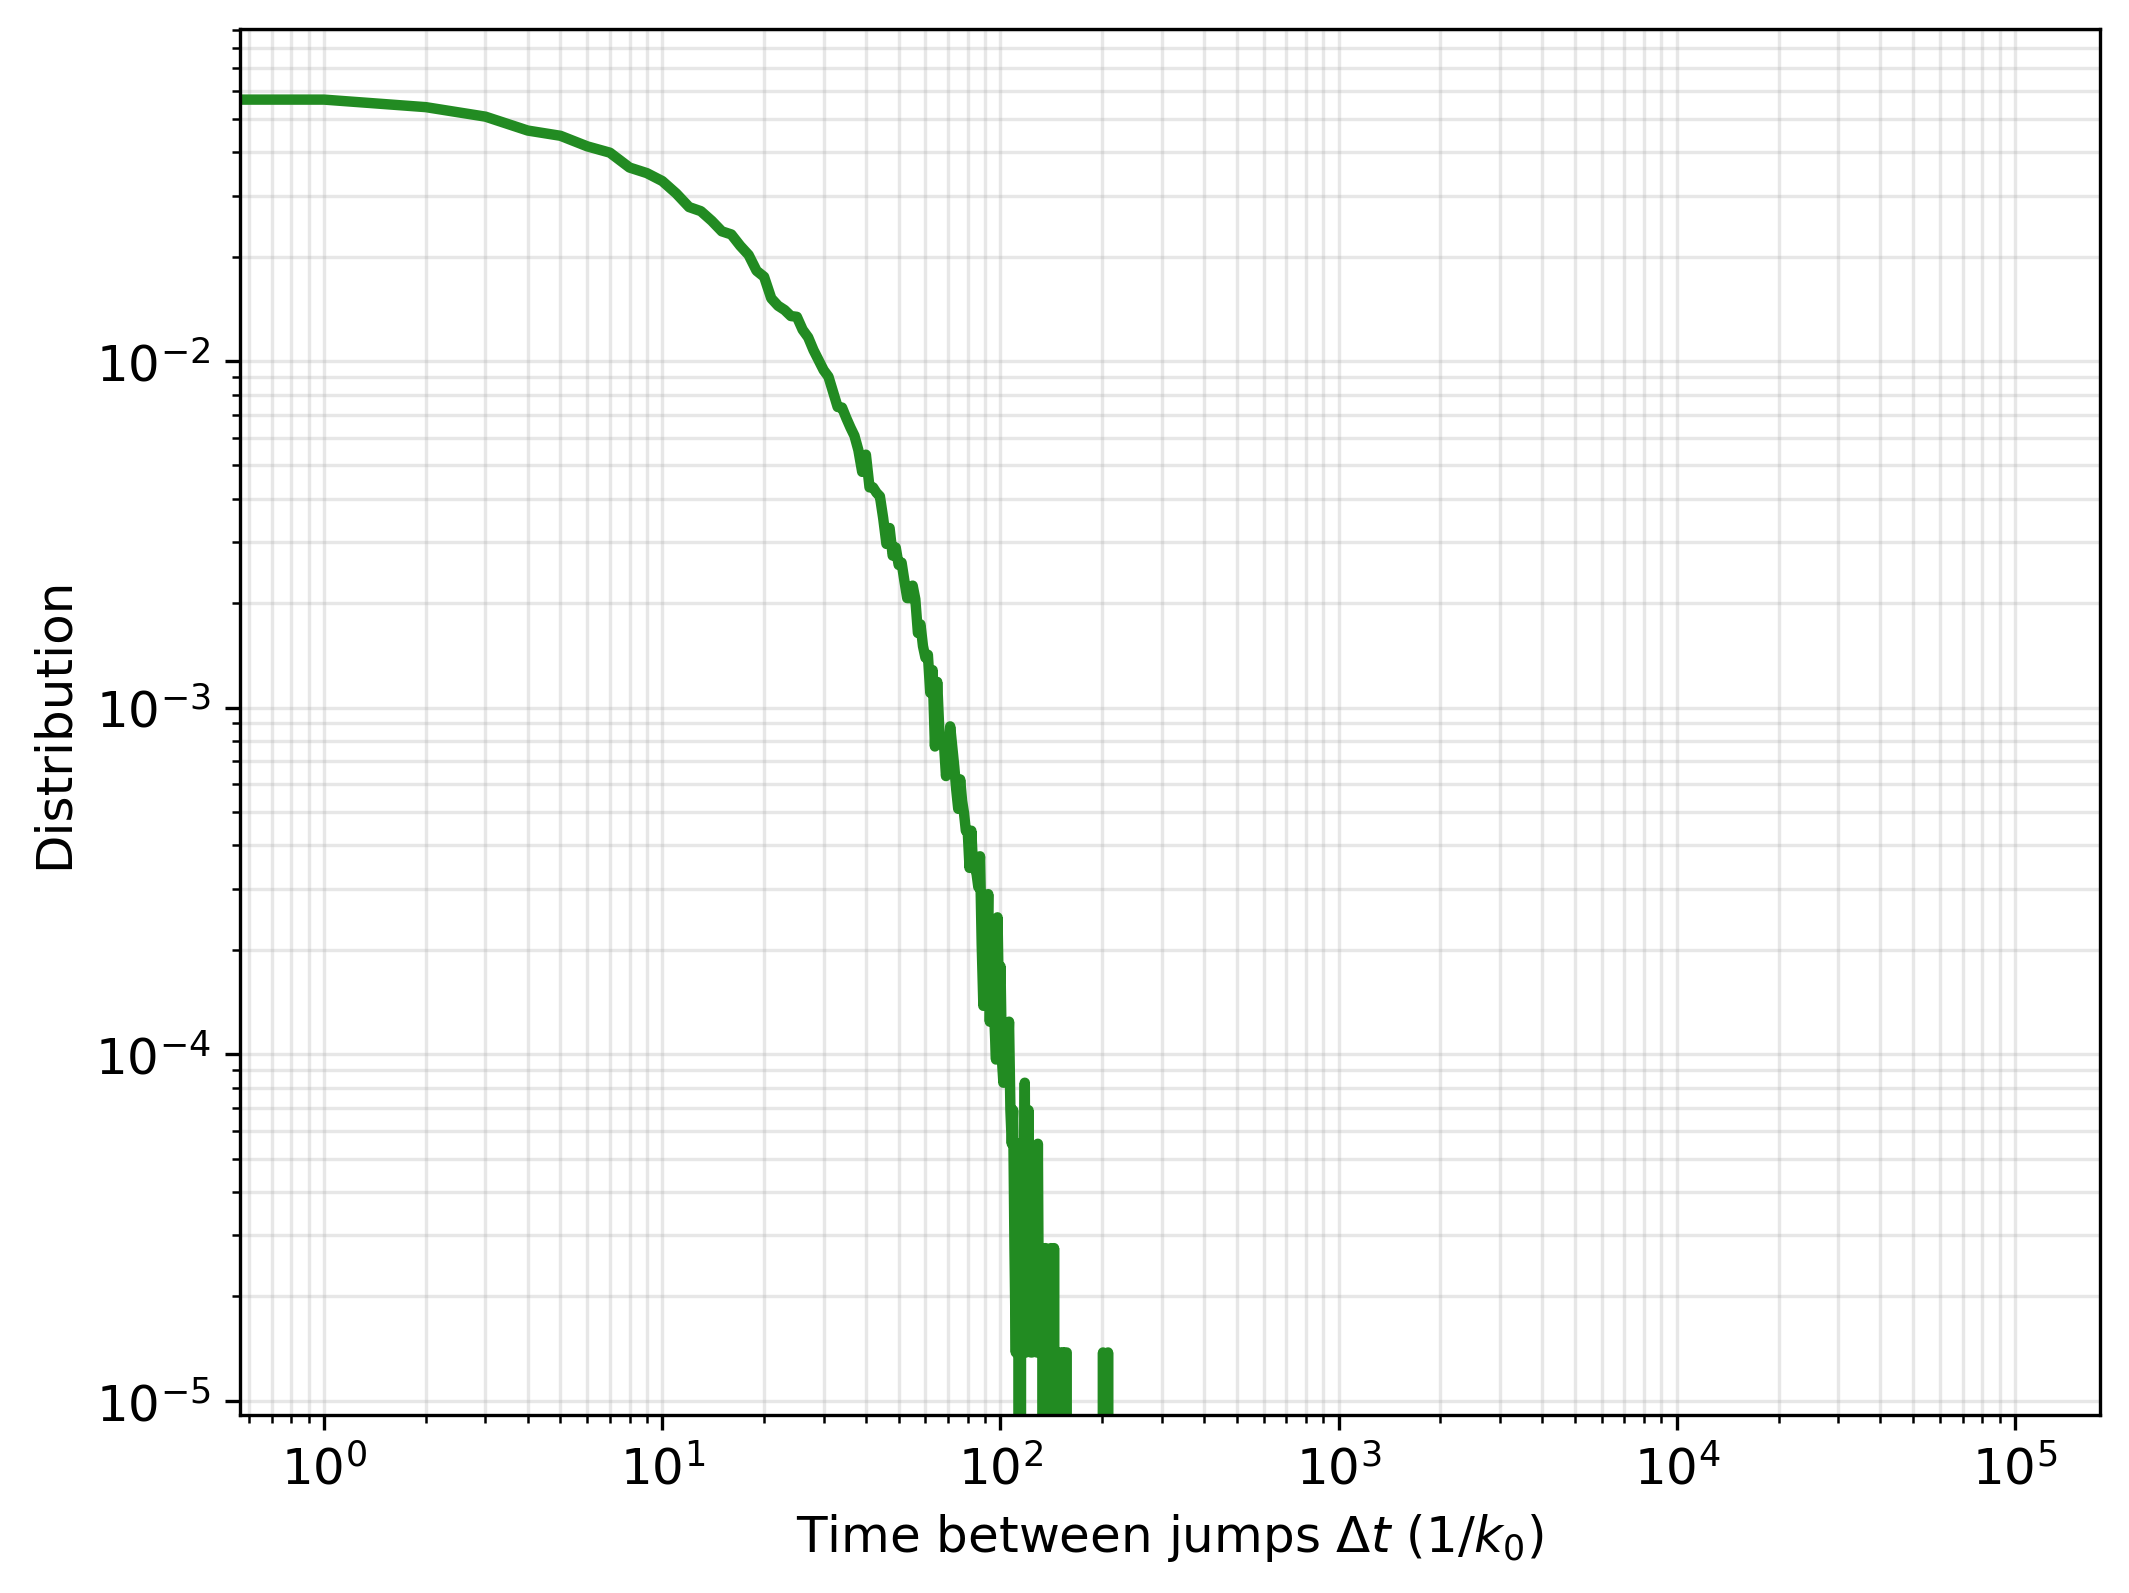

In [3]:
tbj_points = df["tbj_points"][0].to_numpy()
tbj_distrib = df["tbj_distrib"][0].to_numpy()
vi_points = df["vi_points"][0].to_numpy()
vi_distrib = df["vi_distrib"][0].to_numpy()

plt.figure(figsize=(8, 6), dpi=300)

# --- Time between jumps ---
plt.plot(
    tbj_points,
    tbj_distrib,
    color="forestgreen",
    linewidth=2.5,
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Time between jumps $\Delta t$ (1/$k_0$)")
plt.ylabel("Distribution")
plt.grid(True, alpha=0.3, which="both", linestyle="-")
plt.show()


Loading subfiles:  13%|█▎        | 25/192 [00:00<00:02, 82.09subfiles/s] 



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-07-09/nucleo__nu__2/algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


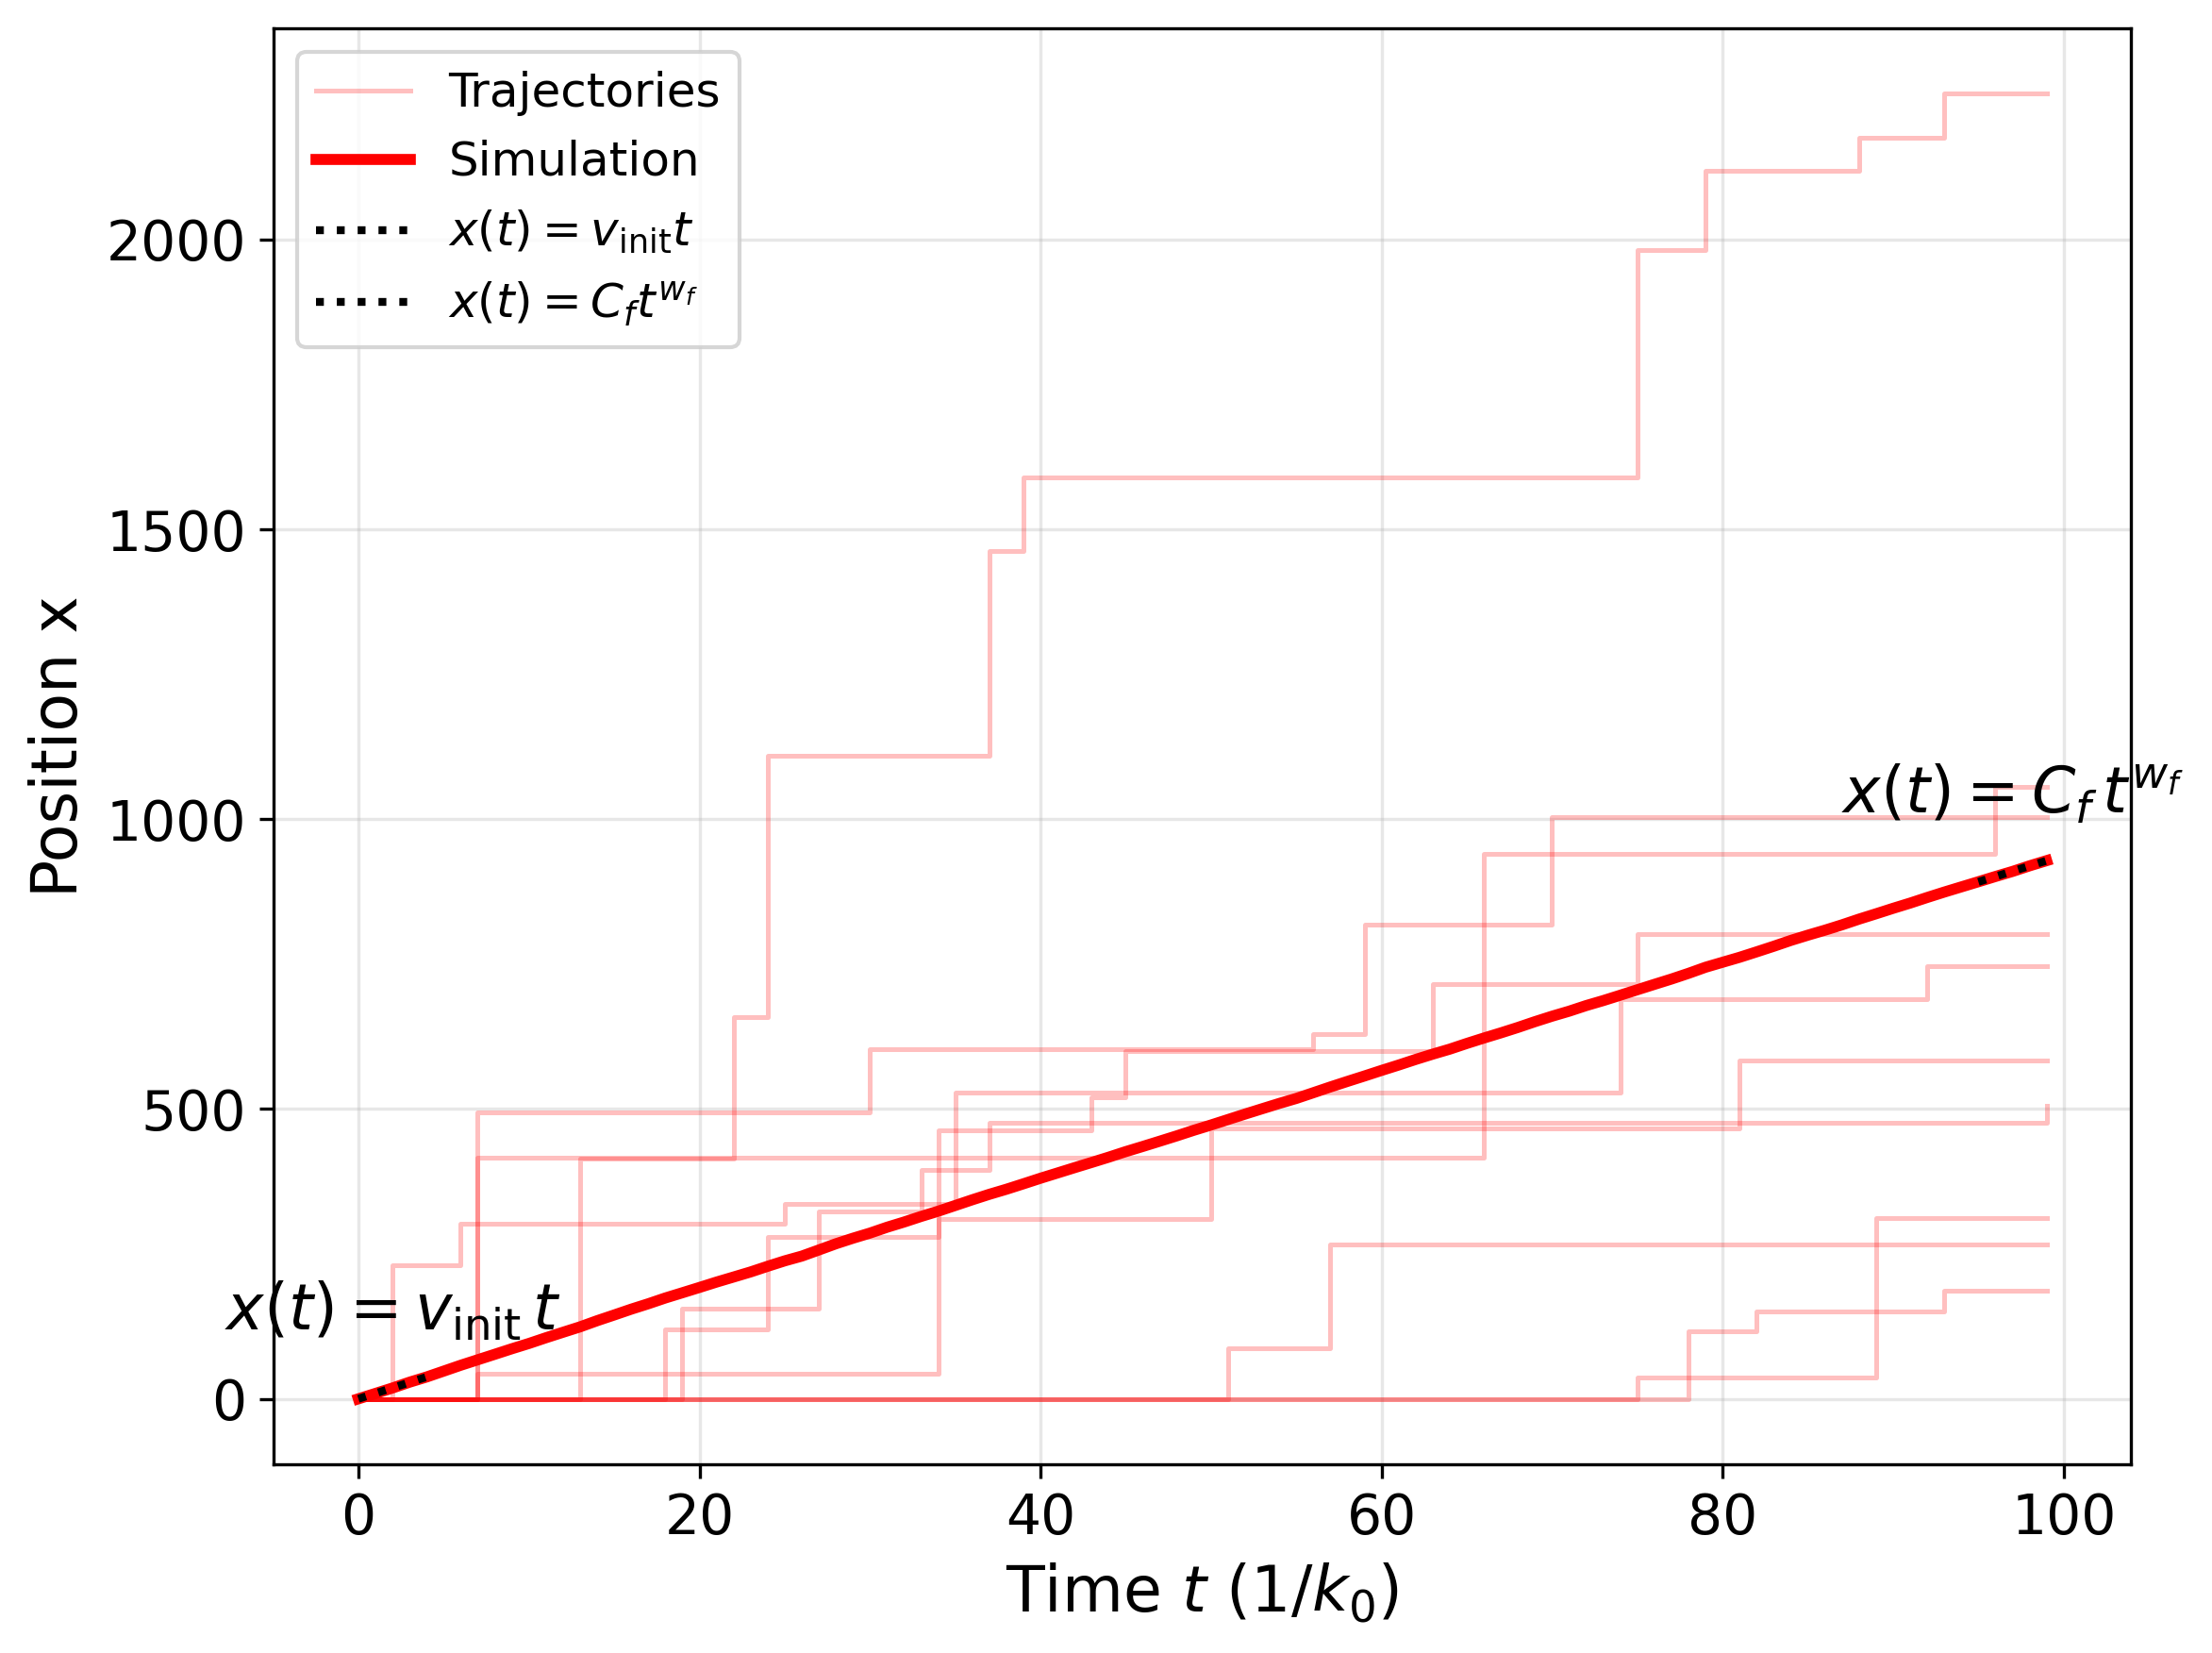

In [4]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.size"] = 12

# Chargement
df = find_parquet_and_load(**params)

times = df["times"][0].to_numpy()
results = df["results"][0].to_numpy()
vf = df["vf"].to_numpy()
Cf = df["Cf"].to_numpy()
wf = df["wf"].to_numpy()


# Moyenne des trajectoires
mean_traj = np.mean(results, axis=0)

plt.figure(figsize=(8, 6), dpi=300)

# Fits début et fin
t_fit_init = times[0:5]
x_fit_init = vf * t_fit_init

t_fit_final = times[95:100]
x_fit_final = Cf * t_fit_final**wf

# Trajectoires individuelles
for i in range(10):
    plt.step(
        times,
        results[i],
        where="post",
        color="red",
        alpha=0.25,
        linewidth=1.2,
        label="Trajectories" if i == 0 else None,
    )

# Trajectoire moyenne
plt.plot(
    times,
    mean_traj,
    color="red",
    linewidth=2.8,
    label="Simulation",
)

# Fit initial (linéaire) 
plt.plot( t_fit_init, x_fit_init, color="black", linestyle=":", linewidth=2, label=r"$x(t)=v_{\mathrm{init}}t$", )

# Fit final (puissance)
plt.plot(
    t_fit_final,
    x_fit_final,
    color="black",
    linestyle=":",
    linewidth=2,
    label=r"$x(t)=C_f t^{w_f}$",
)

# Annotations
plt.text(
    t_fit_init[len(t_fit_init)//2],
    x_fit_init[len(x_fit_init)//2] + 100,
    r"$x(t)=v_{\mathrm{init}}\,t$",
    fontsize=16,
    ha="center",
)

plt.text(
    t_fit_final[len(t_fit_final)//2],
    x_fit_final[len(x_fit_final)//2] + 100,
    r"$x(t)=C_f\,t^{w_f}$",
    fontsize=16,
    ha="center",
)

# Mise en forme
plt.xlabel(r"Time $t$ $(1/k_0)$", fontsize=16)
plt.ylabel("Position x", fontsize=16)

plt.tick_params(labelsize=14)
plt.grid(True, alpha=0.3)

plt.legend(fontsize=12)
# ax.set_title(r"$\mu = 160,\ \theta = 20$", fontsize=18)

plt.tight_layout()
plt.show()

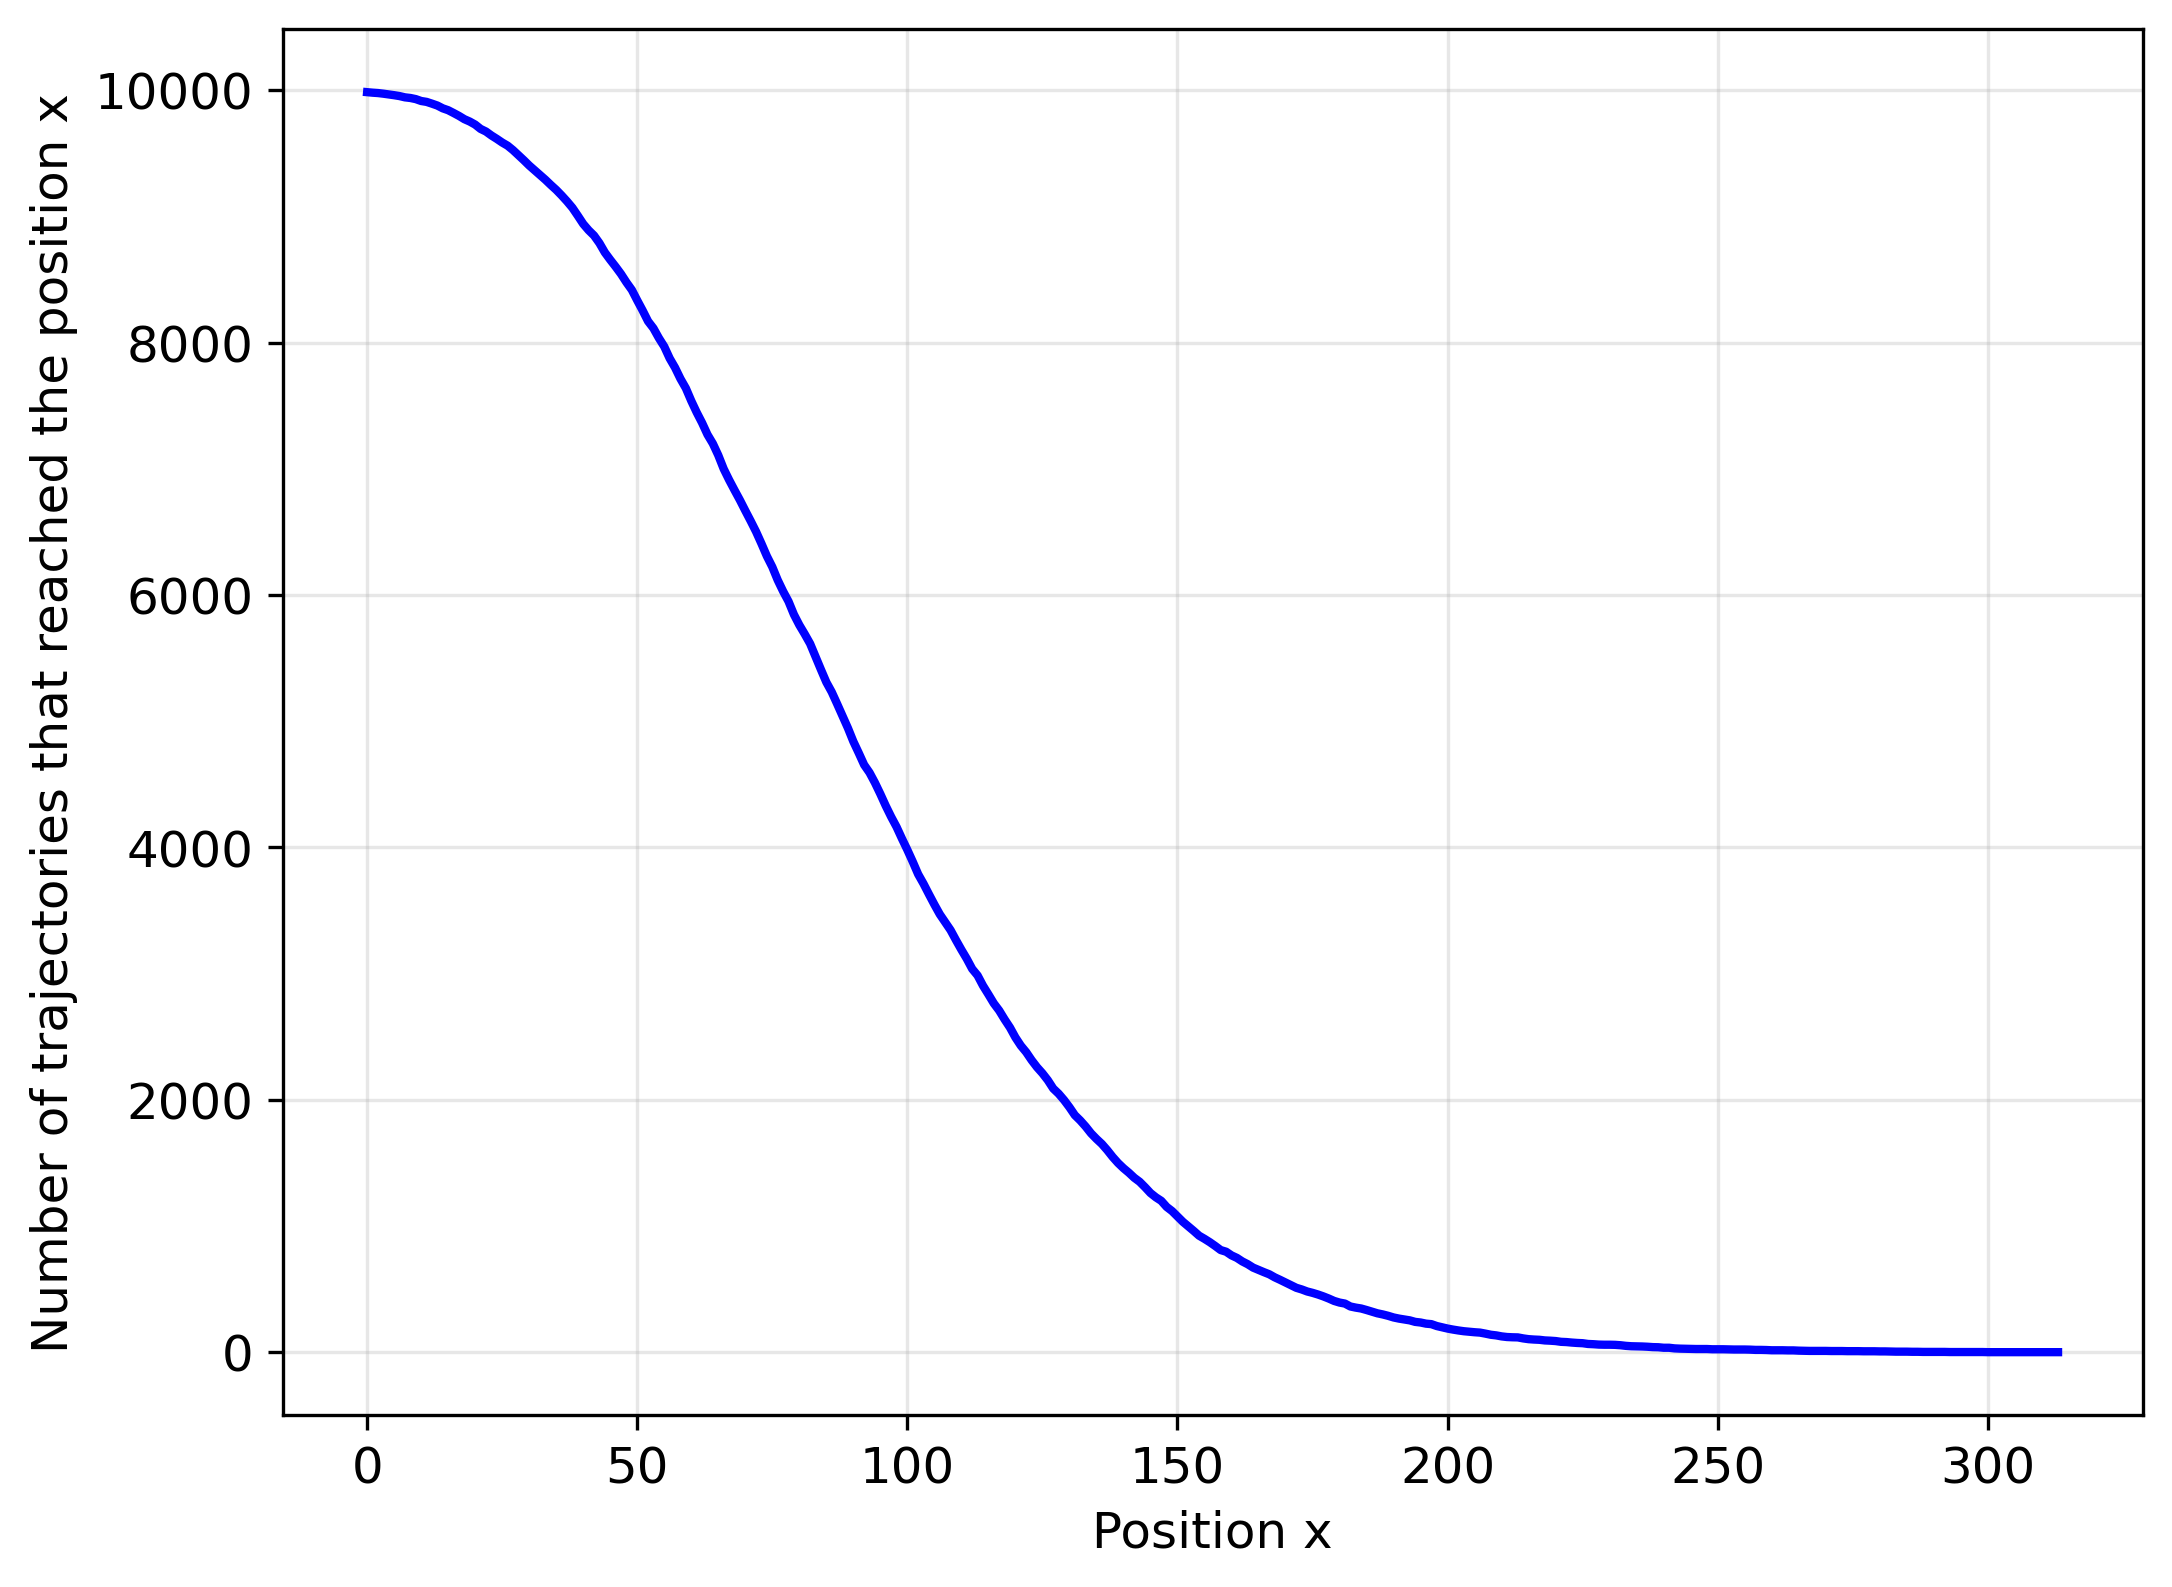

In [5]:
plt.figure(figsize=(8, 6), dpi=300)
plt.rcParams["font.size"] = 12
n_reached = df["fpt_number"][0].to_numpy()
plt.plot(n_reached, color="blue", linewidth=2.0)
plt.xlabel("Position x")
plt.ylabel("Number of trajectories that reached the position x")
plt.grid(True, alpha=0.30)
plt.show()

float64
(102, 314)
<class 'numpy.ndarray'>
(314,)


<Axes: title={'center': 'Distribution of FPTs'}, xlabel='Position x', ylabel='Time t'>

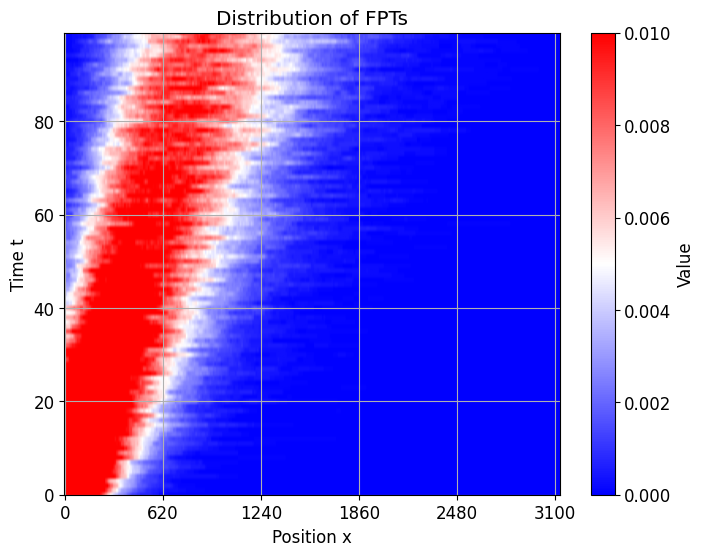

In [6]:
from nucleo.io.plots_1D import plot_fpt_distrib_2d
plt.rcParams["font.size"] = 12


fpt_distrib = df["fpt_distrib"][0].to_numpy()
fpt_distrib = np.stack(fpt_distrib)
tmax = df["tmax"][0]
bint = df["bint"][0]

print(fpt_distrib.dtype)
print(fpt_distrib.shape)
print(type(fpt_distrib[0]))
print(fpt_distrib[0].shape)

plot_fpt_distrib_2d(
    fpt_distrib_2D=fpt_distrib,
    tmax=tmax,
    time_bin=bint,
)

/tmp/ipykernel_42544/4029698631.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


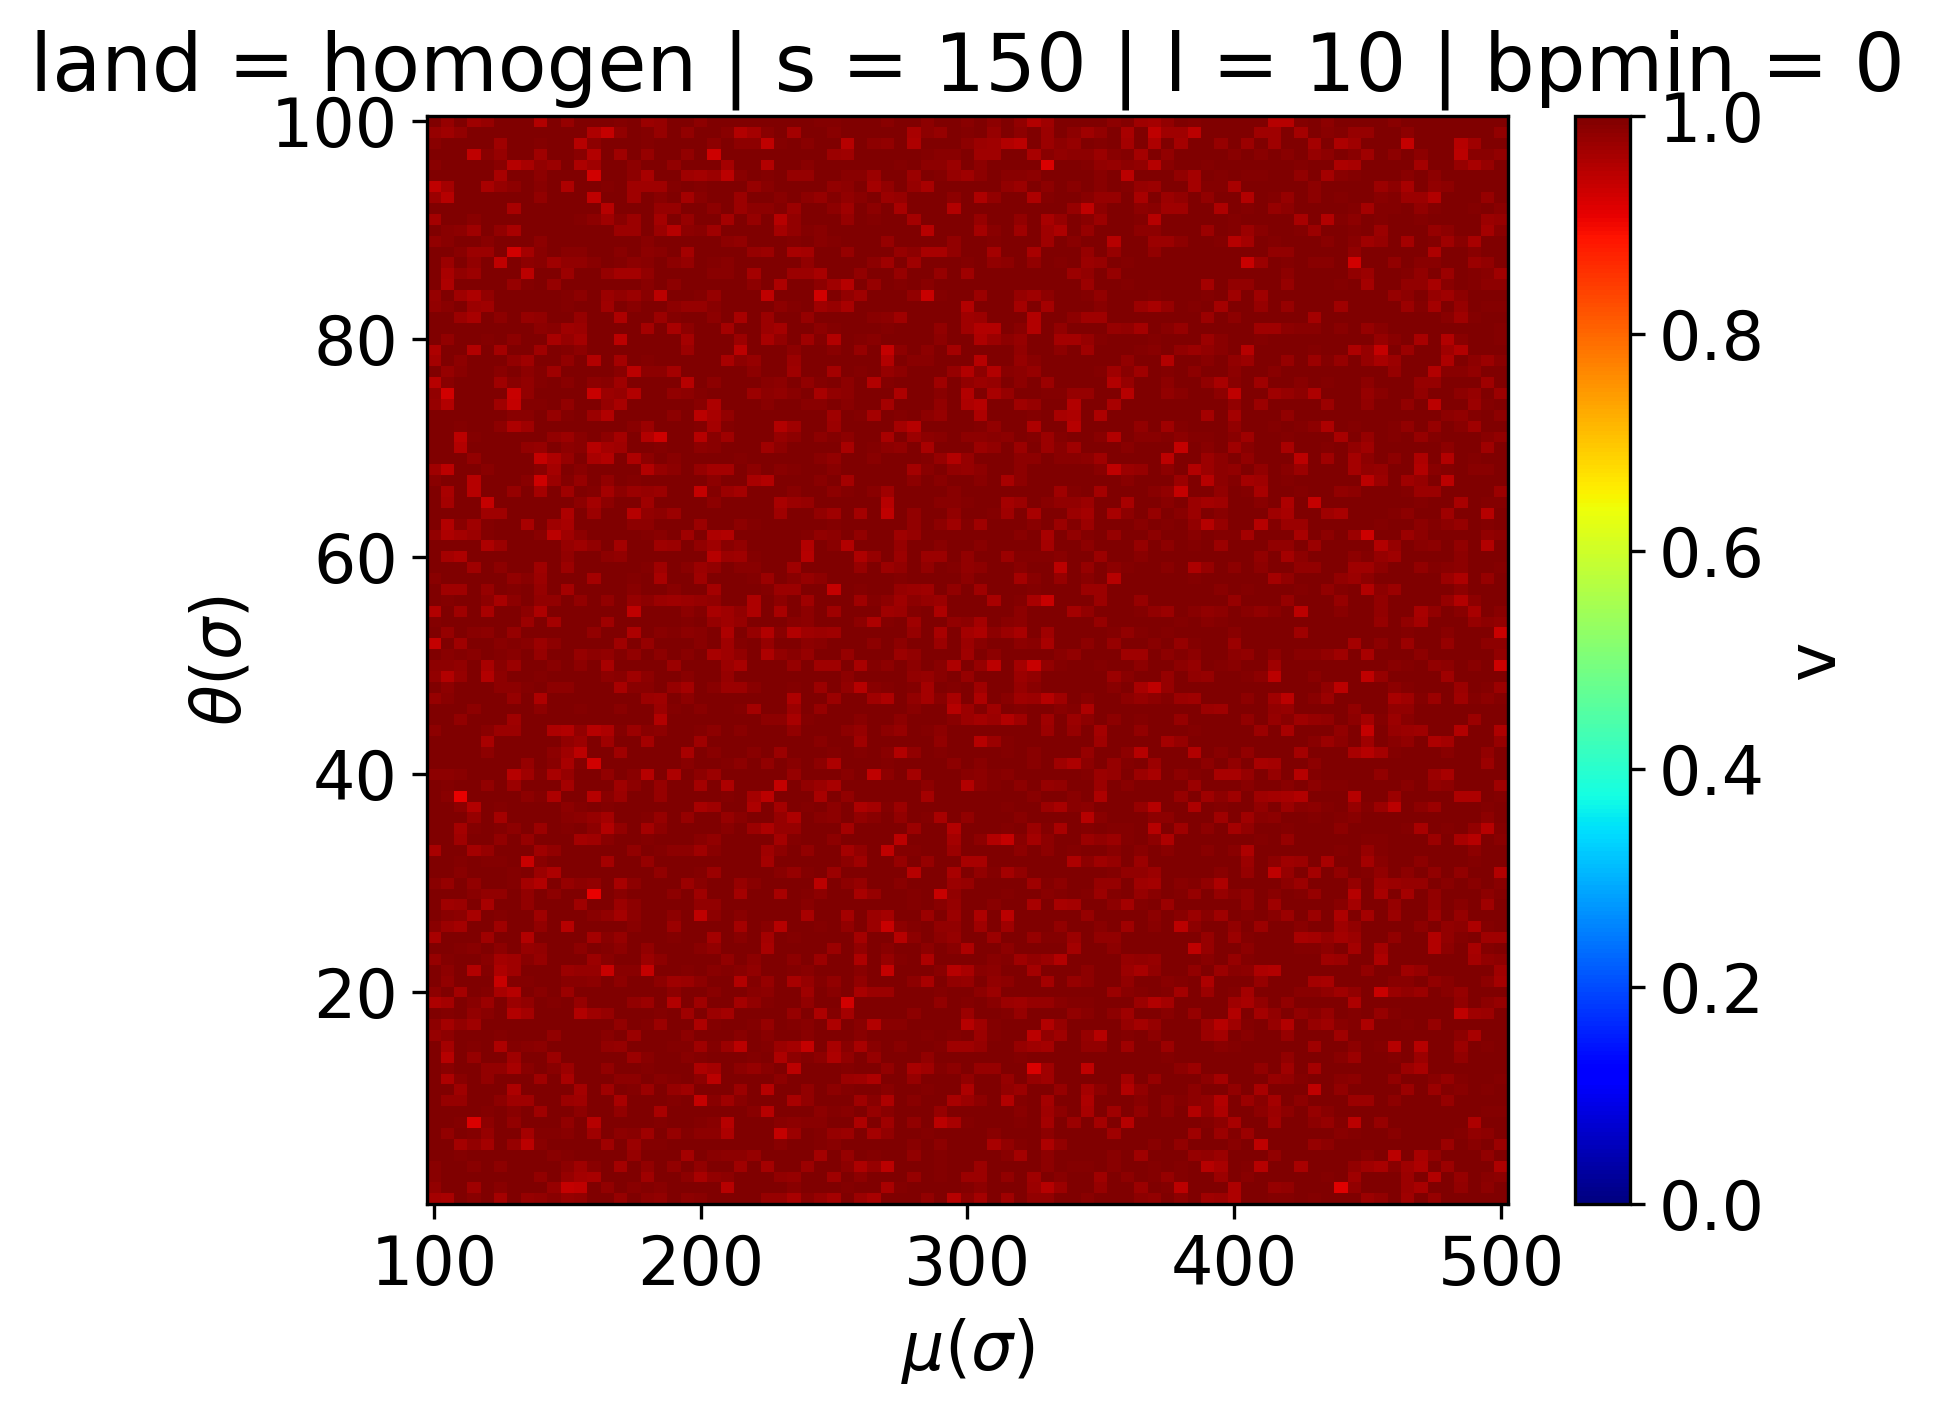

<Figure size 640x480 with 0 Axes>

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from nucleo.io.plots_2D import plot_one_heatmap_from_df

plt.rcParams["font.size"] = 16

# ── Data ───────────────────────────────
root = Path(
    "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-07-09"
)
heatmaps_df = pl.read_parquet(root / "ncl_heatmaps.parquet")
# points = [(160, 20), (160, 60), (240, 20), (240, 60)]

# ── Couleurs (une couleur par point sélectionné) ─────────────────────────────
cmap = cm.get_cmap("plasma")
# color_positions = np.linspace(0.1, 0.9, len(points))
# color_list = [cmap(pos) for pos in color_positions]

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
plot_one_heatmap_from_df(
    heatmaps_df,
    config_idx=19,        # équivalent du `key` de l'ancien dict (premier idx = 0) # MAX 19 (homogen)
    speed_col="wf",
    ax=ax,
    type_of_data="raw",
    plot_log2=False,
    dashed_line=False,
    title=False,
)

# for i, (mu_pt, theta_pt) in enumerate(points):
#     ax.scatter(
#         mu_pt,
#         theta_pt,
#         color=color_list[i],
#         s=100,              # taille du point
#         edgecolor="black",  # contour du point
#         zorder=10           # pour être au-dessus de la heatmap
#     )

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

# .